# Zero-Age Main Sequence (ZAMS) Stellar Structure Calculation
**Abby Tejera Rocha**

Here I compute the interior structure of a 1 M_sun ZAMS star by solving the four coupled ODEs of stellar structure using the shooting method. Outward integrations from just above the center and inward integrations from the photosphere are matched at a fitting point (m = 0.5 M_star), and the four boundary parameters (P_c, T_c, L_star, R_star) are iterated until convergence.

Composition: X = 0.70, Y = 0.28, Z = 0.02 (solar-like).

## Imports:

In [596]:
# Imports I need:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.io import ascii
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import solve_ivp
from scipy import optimize

# Nice plot defaults:
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})
print('Imports successful.')

Imports successful.


## Physical Constants (CGS)
All constants are in CGS units throughout this notebook.

In [599]:
# Fundamental constants:
G      = 6.67430e-8        # gravitational constant [cm^3 g^-1 s^-2]
c_light= 2.99792458e10     # speed of light [cm/s]
k_B    = 1.380649e-16      # Boltzmann constant [erg/K]
N_A    = 6.02214076e23     # Avogadro's number [mol^-1]
h_P    = 6.6260755e-27     # Planck constant [erg s]
m_p    = 1.6726231e-24     # proton mass [g]
a_rad  = 7.5657e-15        # radiation constant [erg cm^-3 K^-4]
sigma_sb = 5.670374419e-5  # Stefan-Boltzmann constant [erg cm^-2 K^-4 s^-1]

# Solar reference values
M_sun  = 1.989e33          # solar mass [g]
R_sun  = 6.96e10           # solar radius [cm]
L_sun  = 3.826e33          # solar luminosity [erg/s]

print('Physical constants defined.')
print(f'  G       = {G:.5e} cm^3 g^-1 s^-2')
print(f'  a_rad   = {a_rad:.5e} erg cm^-3 K^-4')
print(f'  sigma_sb= {sigma_sb:.5e} erg cm^-2 K^-4 s^-1')

Physical constants defined.
  G       = 6.67430e-08 cm^3 g^-1 s^-2
  a_rad   = 7.56570e-15 erg cm^-3 K^-4
  sigma_sb= 5.67037e-05 erg cm^-2 K^-4 s^-1


## Stellar Parameters and Initial Guesses
I model a **1 M_sun star** with solar composition. The four unknowns for which I must supply initial guesses are the central pressure P_c, central temperature T_c, total luminosity L_star, and total radius R_star.

In [602]:
# Composition:
X = 0.70   # hydrogen mass fraction
Y = 0.28   # helium mass fraction
Z = 0.02   # metal mass fraction  (Z = 1 - X - Y)
assert abs(X + Y + Z - 1.0) < 1e-10, 'Composition fractions must sum to 1.'

# Total stellar mass:
M_star = 1.0 * M_sun       # [g]

# Initial guesses for boundary parameters:
# Central pressure (order-of-magnitude estimate for a solar-type star)
P_c_guess = 2.5e17         # [dyn cm^-2]

# Central temperature, estimate of typical solar core value
T_c_guess = 1.5e7          # [K]

# Surface luminosity and radius
L_guess   = 1.0 * L_sun    # [erg/s]
R_guess   = 1.0 * R_sun    # [cm]

# Integration parameters:
M_r_inner = 1e-10 * M_star # tiny enclosed mass just above centre (to avoid r=0 singularity)
M_fit     = 0.5 * M_star  # fitting-point mass (I'll shoot inward and outward to here)
n_steps   = 1000           # number of evaluation points per integration leg

# Opacity table file:
OPACITY_FILE = 'opacity_x0.7y0.28z0.02.txt'

print('Stellar parameters set.')
print(f'  Mass = {M_star/M_sun:.2f} M_sun')
print(f'  X={X}, Y={Y}, Z={Z}')
print(f'  Initial guesses: P_c={P_c_guess:.2e}, T_c={T_c_guess:.2e}, L={L_guess/L_sun:.1f} L_sun, R={R_guess/R_sun:.1f} R_sun')

Stellar parameters set.
  Mass = 1.00 M_sun
  X=0.7, Y=0.28, Z=0.02
  Initial guesses: P_c=2.50e+17, T_c=1.50e+07, L=1.0 L_sun, R=1.0 R_sun


## Equation of State:
I assume a fully ionized ideal gas plus radiation pressure:

$$P = P_{\rm gas} + P_{\rm rad} = \frac{\rho N_A k_B T}{\mu} + \frac{a T^4}{3}$$

Solving for density $\rho$:

$$\rho = \frac{(P - a T^4/3)\,\mu}{N_A k_B T}$$

The mean molecular weight for a fully ionized gas with negligible metals:

$$\mu = \frac{4}{3 + 5X}$$

I also compute the gas pressure fraction $\beta = P_{\rm gas}/P$ for use in the adiabatic gradient.

In [605]:
def compute_mean_mol_weight(X):
    """
    Mean molecular weight for a fully ionized gas with negligible metals.
    Eq. 1.55: mu = 4 / (3 + 5X)
    """
    return 4.0 / (3.0 + 5.0 * X)


def compute_density(P, T, X):
    """
    Density [g/cm^3] from total pressure P [dyn/cm^2] and temperature T [K]
    for a fully ionized ideal gas + radiation.

    From P = P_gas + P_rad = (rho * N_A * k_B * T / mu) + (a * T^4 / 3)
    => rho = (P - P_rad) * mu / (N_A * k_B * T)
    """
    mu    = compute_mean_mol_weight(X)
    P_rad = (a_rad * T**4) / 3.0         # radiation pressure (Eq. 3.17)
    P_gas = P - P_rad                    # gas pressure
    if np.any(P_gas <= 0):
        # Physically unphysical region; returning a large density to guide the solver away
        return np.where(P_gas <= 0, 1e-30, (mu * P_gas) / (N_A * k_B * T))
    rho = (mu * P_gas) / (N_A * k_B * T)
    return rho


def compute_beta(P, T, X):
    """
    Gas pressure fraction beta = P_gas / P_total.
    Also returns rho.
    """
    mu    = compute_mean_mol_weight(X)
    P_rad = (a_rad * T**4) / 3.0
    P_gas = P - P_rad
    rho   = (mu * P_gas) / (N_A * k_B * T)
    beta  = P_gas / P
    return beta, rho


# Quick sanity check from Homework 2 cases:
cases = [
    {'label': 'HW Case 1 (X=0, Y=0.98)', 'X': 0.0, 'logT': 7.55, 'logP': 16.85},
    {'label': 'HW Case 2 (X=0.70)',       'X': 0.70,'logT': 6.91, 'logP': 16.87},
]
print('EOS sanity checks:')
for c in cases:
    T = 10**c['logT']; P = 10**c['logP']
    rho = compute_density(P, T, c['X'])
    beta, _ = compute_beta(P, T, c['X'])
    mu = compute_mean_mol_weight(c['X'])
    print(f"  {c['label']}:  mu={mu:.4f},  rho={rho:.3e} g/cm^3,  beta={beta:.6f}")

EOS sanity checks:
  HW Case 1 (X=0, Y=0.98):  mu=1.3333,  rho=3.019e+01 g/cm^3,  beta=0.943542
  HW Case 2 (X=0.70):  mu=0.6154,  rho=6.749e+01 g/cm^3,  beta=0.999851


## Opacity:
I load the opacity table (indexed by log T and log R, where $R = \rho / T_6^3$ and $T_6 = T/10^6\,{\rm K}$).

In [608]:
def load_opacity_table(filename):
    """
    Loads an opacity table from a text file.
    Returns:
        logT_vals   : 1-D array of log10(T/K) grid points
        logR_vals   : 1-D array of log10(R) grid points
        log_kappa_g : 2-D array (n_logT x n_logR) of log10(kappa) values
    """
    table       = ascii.read(filename, data_start=3, header_start=2)
    logR_vals   = np.array([float(col) for col in table.colnames[1:]])
    logT_vals   = np.array(table['logT'])
    log_kappa_g = np.array([table[col] for col in table.colnames[1:]]).T  # shape (nT, nR)
    return logT_vals, logR_vals, log_kappa_g


def build_opacity_interpolator(logT_vals, logR_vals, log_kappa_g):
    """
    Builds and returns a RegularGridInterpolator for log10(kappa) on the (logT, logR) grid.
    Uses linear interpolation with extrapolation allowed at boundaries.
    """
    interp = RegularGridInterpolator(
        (logT_vals, logR_vals),
        log_kappa_g,
        method='linear',
        bounds_error=False,
        fill_value=None,   # extrapolating near edges
    )
    return interp


def get_opacity(rho, T, opacity_interp):
    """
    Returns mean opacity kappa [cm^2/g] at density rho [g/cm^3] and
    temperature T [K] by interpolating the opacity table.

    The opacity table is indexed by log10(R) where R = rho / (T/1e6)^3.
    I also enforce the table minimum T to avoid out-of-range extrapolation.
    """
    T   = np.maximum(T,   10**3.75)   # table lower T bound
    rho = np.maximum(rho, 1e-9)       # avoiding log(0)
    T6  = T * 1e-6
    R   = np.maximum(rho / T6**3, 1e-8)
    logT = np.log10(T)
    logR = np.log10(R)
    # interpolator expects shape (..., 2) input
    log_kappa = opacity_interp([[logT, logR]])[0]
    return 10**log_kappa


# Loading the table once and building the interpolator:
logT_tab, logR_tab, logK_tab = load_opacity_table(OPACITY_FILE)
opacity_interp = build_opacity_interpolator(logT_tab, logR_tab, logK_tab)
print(f'Opacity table loaded from "{OPACITY_FILE}"')
print(f'  logT range: [{logT_tab.min():.2f}, {logT_tab.max():.2f}]')
print(f'  logR range: [{logR_tab.min():.2f}, {logR_tab.max():.2f}]')

# Homework based sanity checks:
k1 = get_opacity(10**0.3,  10**6.3, opacity_interp)
k2 = get_opacity(10**(-4), 10**5.0, opacity_interp)
print(f'\nOpacity checks:')
print(f'  kappa(log rho=0.3,  log T=6.3) = {k1:.3e} cm^2/g  (expect ~7.6e+01)')
print(f'  kappa(log rho=-4,   log T=5.0) = {k2:.3e} cm^2/g  (expect ~2.9e+03)')

Opacity table loaded from "opacity_x0.7y0.28z0.02.txt"
  logT range: [3.75, 8.70]
  logR range: [-8.00, 1.00]

Opacity checks:
  kappa(log rho=0.3,  log T=6.3) = 7.558e+01 cm^2/g  (expect ~7.6e+01)
  kappa(log rho=-4,   log T=5.0) = 2.917e+03 cm^2/g  (expect ~2.9e+03)


## Nuclear energy generation:
Energy generation from hydrogen fusion comes from both the **proton–proton (PP) chains** and the **CNO cycle**. I use the analytical approximations.

In [611]:
def energy_gen_pp(rho, T, X, Y, Z):
    """
    PP-chain energy generation rate [erg g^-1 s^-1].
    Weak screening for f11 (valid for stellar interiors).
    """
    T9  = T / 1e9  # T in units of 10^9 K
    T7  = T / 1e7  # T in units of 10^7 K
    # Temperature correction factor g11
    g11 = 1 + 3.82*T9 + 1.51*T9**2 + 0.144*T9**3 - 0.0114*T9**4
    # Weak screening factor f11
    f11 = np.exp(5.92e-3 * np.sqrt(rho / T7**3))
    psi = 1.0   
    eps_pp = (
        2.57e4 * psi * f11 * g11
        * rho * X**2
        * T9**(-2/3)
        * np.exp(-3.381 / T9**(1/3))
    )
    return eps_pp


def energy_gen_cno(rho, T, X, Y, Z):
    """
    CNO-cycle energy generation rate [erg g^-1 s^-1] at equilibrium.
    X_CNO uses solar CNO mass-fraction ratios scaled by Z.
    """
    T9    = T / 1e9
    # Temperature correction factor g14
    g14   = 1 - 2*T9 + 3.41*T9**2 - 2.43*T9**3
    # CNO mass fraction: C+N+O fractions from solar proportions times Z
    X_CNO = (0.173 + 0.053 + 0.482) * Z
    eps_cno = (
        8.24e25 * g14 * X_CNO * X
        * rho * T9**(-2/3)
        * np.exp(-15.231 / T9**(1/3) - (T9/0.8)**2)
    )
    return eps_cno


def total_energy_gen(rho, T, X, Y, Z):
    """
    Total nuclear energy generation rate [erg g^-1 s^-1] = eps_pp + eps_CNO.
    """
    return energy_gen_pp(rho, T, X, Y, Z) + energy_gen_cno(rho, T, X, Y, Z)


# Homework sanity check:
rho_hw = 10**1.90
T_hw   = 10**7.25
eps_pp_hw  = energy_gen_pp(rho_hw,  T_hw, X, Y, Z)
eps_cno_hw = energy_gen_cno(rho_hw, T_hw, X, Y, Z)
print('Energy generation sanity check:')
print(f'  rho = {rho_hw:.3e} g/cm^3,  T = {T_hw:.3e} K')
print(f'  eps_pp  = {eps_pp_hw:.3e} erg/g/s   (expect ~3.8e+01)')
print(f'  eps_CNO = {eps_cno_hw:.3e} erg/g/s  (expect ~4.2e+01)')
print(f'  ratio eps_pp/eps_CNO = {eps_pp_hw/eps_cno_hw:.3f}  (expect ~0.91)')

Energy generation sanity check:
  rho = 7.943e+01 g/cm^3,  T = 1.778e+07 K
  eps_pp  = 3.799e+01 erg/g/s   (expect ~3.8e+01)
  eps_CNO = 4.178e+01 erg/g/s  (expect ~4.2e+01)
  ratio eps_pp/eps_CNO = 0.909  (expect ~0.91)


## Temperature gradients:
The actual temperature gradient $\nabla = d\ln T/d\ln P$ is the **minimum** of the radiative and adiabatic gradients.

**Radiative gradient**:
$$\nabla_{\rm rad} = \frac{3}{16\pi} \frac{\kappa L_r P}{a c G m T^4}$$

**Adiabatic gradient** for a gas+radiation mixture:
$$\nabla_{\rm ad} = \frac{2(4-3\beta)}{32 - 24\beta - 3\beta^2}$$

If $\nabla_{\rm rad} \le \nabla_{\rm ad}$, the shell is **radiative**; otherwise it is **convective** and $\nabla = \nabla_{\rm ad}$.

In [614]:
def compute_del_rad(L_r, P, T, m, X, opacity_interp):
    """
    Radiative temperature gradient del_rad = d ln T / d ln P (radiative).
    del_rad = (3 kappa L_r P) / (16 pi a c G m T^4)
    """
    rho   = compute_density(P, T, X)
    kappa = get_opacity(rho, T, opacity_interp)
    del_rad = (3.0 / (16.0 * np.pi)) * P * kappa * L_r / (a_rad * c_light * G * m * T**4)
    return del_rad


def compute_del_ad(P, T, X):
    """
    Adiabatic temperature gradient del_ad for a gas + radiation mixture.
    del_ad = 2(4 - 3 beta) / (32 - 24 beta - 3 beta^2)
    """
    beta, _ = compute_beta(P, T, X)
    del_ad  = 2.0 * (4.0 - 3.0*beta) / (32.0 - 24.0*beta - 3.0*beta**2)
    return del_ad


def compute_actual_del(L_r, P, T, m, X, opacity_interp):
    """
    Actual temperature gradient.
    Returns del_rad if layer is radiative, del_ad if convective.
    Also returns whether the layer is convective (True/False).
    """
    del_rad = compute_del_rad(L_r, P, T, m, X, opacity_interp)
    del_ad  = compute_del_ad(P, T, X)
    if del_rad <= del_ad:
        return del_rad, False   # radiative
    else:
        return del_ad, True     # convective


print('Temperature gradient functions defined.')

Temperature gradient functions defined.


## Stellar structure ODEs — `derivs`

$$\frac{dl}{dm} = \varepsilon, \qquad
  \frac{dP}{dm} = -\frac{Gm}{4\pi r^4}, \qquad
  \frac{dr}{dm} = \frac{1}{4\pi r^2 \rho}, \qquad
  \frac{dT}{dm} = -\frac{GmT}{4\pi r^4 P}\,\nabla$$

In [617]:
def stellar_derivs(m, state, X, Y, Z, opacity_interp):
    """
    Right-hand sides of the four stellar-structure ODEs in mass coordinates.

    Parameters:
    
    m     : float  — enclosed mass [g] (independent variable)
    state : array  — [l, P, r, T]  (luminosity, pressure, radius, temperature)
    X, Y, Z : floats — composition
    opacity_interp : interpolator object

    Returns:
    
    [dl/dm, dP/dm, dr/dm, dT/dm]
    """
    l, P, r, T = state

    rho   = compute_density(P, T, X)
    eps   = total_energy_gen(rho, T, X, Y, Z)              # erg/g/s
    nabla, _ = compute_actual_del(l, P, T, m, X, opacity_interp)

    
    dldm =  eps
    dPdm = -G * m / (4.0 * np.pi * r**4)
    drdm =  1.0 / (4.0 * np.pi * r**2 * rho)
    dTdm = -(G * m * T) / (4.0 * np.pi * r**4 * P) * nabla

    return [dldm, dPdm, drdm, dTdm]


print('Stellar structure ODE right-hand sides (stellar_derivs) defined.')

Stellar structure ODE right-hand sides (stellar_derivs) defined.


## Boundary conditions:

In [620]:
def inner_boundary(M_total, m0, P_c, T_c, X, Y, Z, opacity_interp):
    """
    Inner boundary conditions at very small enclosed mass m0.

    Expands r, l, P, T in powers of m0^(1/3) or m0^(2/3) starting from the
    central values P_c and T_c (which are the free parameters I optimize).

    Returns: [l0, P0, r0, T0]
    """
    rho_c = compute_density(P_c, T_c, X)
    eps_c = total_energy_gen(rho_c, T_c, X, Y, Z)
    kap_c = get_opacity(rho_c, T_c, opacity_interp)

    # Radius near centre
    r0 = (3.0 / (4.0 * np.pi * rho_c))**(1.0/3.0) * m0**(1.0/3.0)

    # Luminosity near centre
    l0 = eps_c * m0

    # Pressure near centre
    P0 = P_c - (3.0*G / (8.0*np.pi)) * (4.0*np.pi/3.0 * rho_c)**(4.0/3.0) * m0**(2.0/3.0)

    # Temperature near centre: radiative vs convective core (threshold ~1.5 M_sun)
    if M_total / M_sun < 1.5:   # radiative core for solar-mass star
        
        T0 = (T_c**4 - (1.0/(2.0*a_rad*c_light)) * (3.0/(4.0*np.pi))**(2.0/3.0)
              * kap_c * eps_c * rho_c**(4.0/3.0) * m0**(2.0/3.0))**(1.0/4.0)
    else:                        # convective core for more massive star
        
        del_ad = compute_del_ad(P_c, T_c, X)
        T0 = np.exp(np.log(T_c) - (np.pi/6.0)**(1.0/3.0)
                    * G * del_ad * rho_c**(4.0/3.0) / P_c * m0**(2.0/3.0))

    return [l0, P0, r0, T0]


def outer_boundary(M_total, R_star, L_star, X, Y, Z, opacity_interp):
    """
    Outer boundary conditions at the photosphere.

    Using the Eddington approximation to get T at tau=2/3,
    and integrating dP/dtau = g/kappa from tau=0 to tau=2/3 to get P.

    Returns: [L_star, P_s, R_star, T_s]
    """
    # Effective temperature
    T_eff = (L_star / (4.0 * np.pi * R_star**2 * sigma_sb))**0.25
    g_surf = G * M_total / R_star**2    # surface gravity

    # Temperature at tau = 2/3 from Eddington approximation
    tau_phot = 2.0/3.0
    T_s = T_eff * (0.75 * (tau_phot + 2.0/3.0))**0.25

    # Integrating dP/dtau = g/kappa from tau=0 to tau=2/3 to get photospheric P
    def dP_dtau(tau, P_arr):
        T_tau = T_eff * (0.75 * (tau + 2.0/3.0))**0.25
        rho_  = compute_density(P_arr[0], T_tau, X)
        kap_  = get_opacity(rho_, T_tau, opacity_interp)
        return [g_surf / kap_]

    sol  = solve_ivp(dP_dtau, [0, tau_phot], y0=[10.0], method='RK45')
    P_s  = sol.y[0, -1]

    return [L_star, P_s, R_star, T_s]


# Sanity check: evaluating both boundaries at guessed parameters:
inner_bc = inner_boundary(M_star, M_r_inner, P_c_guess, T_c_guess, X, Y, Z, opacity_interp)
outer_bc = outer_boundary(M_star, R_guess, L_guess, X, Y, Z, opacity_interp)
print('Boundary conditions (initial guesses):')
print(f'  Inner [l, P, r, T] = {inner_bc}')
print(f'  Outer [l, P, r, T] = {outer_bc}')

Boundary conditions (initial guesses):
  Inner [l, P, r, T] = [6.671543441838757e+24, 2.4999988751854474e+17, 7275602.099425299, 14999993.152509466]
  Outer [l, P, r, T] = [3.826e+33, 113583.25769492546, 69600000000.0, 5770.005424644845]


## Shooting method — Integration:
I integrate the four ODEs **outward** from $m_0$ to $m_{\rm fit}$ and **inward** from M_star to $m_{\rm fit}$ using `scipy.integrate.solve_ivp`.

In [623]:
def integrate_structure(boundary_params, M_total, M_r_inner, M_fit,
                        X, Y, Z, opacity_interp, n_steps=1000):
    """
    Shooting from both boundaries to the fitting point.

    Parameters:
    
    boundary_params : array [L_star, P_c, R_star, T_c] — the four free parameters
    M_total         : total stellar mass [g]
    M_r_inner       : tiny mass above centre [g]
    M_fit           : fitting-point mass [g]
    X, Y, Z         : composition
    opacity_interp  : opacity interpolator
    n_steps         : number of evaluation points per integration leg

    Returns:
    
    outward, inward : solve_ivp result objects
    """
    L_star, P_c, R_star, T_c = boundary_params

    # Mass arrays: outward centre->fit, inward surface->fit
    m_out_eval = np.linspace(M_r_inner, M_fit, n_steps // 2)
    m_in_eval  = np.linspace(M_total,   M_fit, n_steps // 2)

    # Shared ODE arguments
    ode_args = (X, Y, Z, opacity_interp)

    # Outward integration (centre to fitting point):
    ic_inner = inner_boundary(M_total, M_r_inner, P_c, T_c, X, Y, Z, opacity_interp)
    outward  = solve_ivp(
        stellar_derivs,
        [M_r_inner, M_fit],
        ic_inner,
        args=ode_args,
        t_eval=m_out_eval,
        method='RK45',
        rtol=1e-6, atol=1e-8,
    )

    # Inward integration (surface to fitting point):
    ic_outer = outer_boundary(M_total, R_star, L_star, X, Y, Z, opacity_interp)
    inward   = solve_ivp(
        stellar_derivs,
        [M_total, M_fit],
        ic_outer,
        args=ode_args,
        t_eval=m_in_eval,
        method='RK45',
        rtol=1e-6, atol=1e-8,
    )

    return outward, inward


print('integrate_structure defined.')

integrate_structure defined.


## `newt`
The function `shooting_residuals` (analogous to `newt` in Numerical Recipes) calls `integrate_structure`, computes the fractional mismatch of each variable at the fitting point, and returns those residuals. I then pass it to `scipy.optimize.root` to find the boundary parameters $(L_\star, P_c, R_\star, T_c)$ that drive the residuals to zero.

In [626]:
iteration_count = [0]   # mutable list so the callback can increment it

def shooting_residuals(boundary_params, M_total, M_r_inner, M_fit,
                       X, Y, Z, opacity_interp, n_steps=1000):
    """
    Residuals for the shooting-to-a-fitting-point method.

    Returns the fractional mismatch between the outward and inward solutions at
    the fitting point for each of the four dependent variables [l, P, r, T].
    The root finder drives these to zero.
    """
    iteration_count[0] += 1

    # Rejecting unphysical (negative) parameters immediately
    if np.any(np.array(boundary_params) <= 0):
        return [9e99, 9e99, 9e99, 9e99]

    try:
        outward, inward = integrate_structure(
            boundary_params, M_total, M_r_inner, M_fit,
            X, Y, Z, opacity_interp, n_steps
        )
    except Exception:
        return [9e99, 9e99, 9e99, 9e99]

    # Fractional difference at fitting point:
    residuals = []
    for var_idx in range(4):
        val_out = outward.y[var_idx, -1]
        val_in  = inward.y[var_idx, -1]
        frac    = (val_out - val_in) / val_in   # allowing negative residuals
        residuals.append(frac)

    if iteration_count[0] % 10 == 0:
        L, Pc, R, Tc = boundary_params
        print(f'  Iter {iteration_count[0]:3d}: '
              f'L={L/L_sun:.3f} L_sun, R={R/R_sun:.3f} R_sun, '
              f'residuals={[f"{v:.3e}" for v in residuals]}')

    return residuals


print('shooting_residuals defined.')

shooting_residuals defined.


## Running the optimizer:

In [629]:
initial_guess = np.array([L_guess, P_c_guess, R_guess, T_c_guess])

print('=== Running optimizer===')
print(f'Initial guess:  L={L_guess/L_sun:.2f} L_sun,  Pc={P_c_guess:.2e},  '
      f'R={R_guess/R_sun:.2f} R_sun,  Tc={T_c_guess:.2e} K\n')

# Storing the initial-guess integration for later comparison plot
outward_guess, inward_guess = integrate_structure(
    initial_guess, M_star, M_r_inner, M_fit,
    X, Y, Z, opacity_interp, n_steps
)

iteration_count[0] = 0   # resetting counter

sol = optimize.root(
    shooting_residuals,
    initial_guess,
    args=(M_star, M_r_inner, M_fit, X, Y, Z, opacity_interp, n_steps),
    tol=1e-3,
    method='hybr',
)

final_params = sol.x
L_final, Pc_final, R_final, Tc_final = final_params

print(f'\n=== Converged in {iteration_count[0]} iterations ===')
print(f'  L_star  = {L_final:.4e} erg/s  ({L_final/L_sun:.4f} L_sun)')
print(f'  P_c = {Pc_final:.4e} dyn/cm²')
print(f'  R_star  = {R_final:.4e} cm    ({R_final/R_sun:.4f} R_sun)')
print(f'  T_c = {Tc_final:.4e} K')
print(f'  Solver success: {sol.success}  |  message: {sol.message}')

=== Running optimizer===
Initial guess:  L=1.00 L_sun,  Pc=2.50e+17,  R=1.00 R_sun,  Tc=1.50e+07 K

  Iter  10: L=2.206 L_sun, R=1.868 R_sun, residuals=['1.046e-01', '-5.043e-01', '7.981e-03', '-5.578e-01']
  Iter  20: L=0.932 L_sun, R=1.488 R_sun, residuals=['-5.278e-02', '-4.666e-03', '2.770e-02', '-1.656e-01']
  Iter  30: L=0.934 L_sun, R=1.474 R_sun, residuals=['-1.489e-02', '3.337e-02', '5.331e-02', '-2.071e-02']
  Iter  40: L=0.687 L_sun, R=1.417 R_sun, residuals=['-2.643e-03', '3.799e-02', '1.312e-02', '7.718e-03']

=== Converged in 44 iterations ===
  L_star  = 2.2606e+33 erg/s  (0.5908 L_sun)
  P_c = 1.4115e+17 dyn/cm²
  R_star  = 9.6000e+10 cm    (1.3793 R_sun)
  T_c = 1.3088e+07 K
  Solver success: True  |  message: The solution converged.


In [631]:
# Checking final residuals at converged solution
iteration_count[0] = 0  # resetting so this call doesn't mess up the count
final_residuals = shooting_residuals(final_params, M_star, M_r_inner, M_fit, X, Y, Z, opacity_interp, n_steps)
print(f'Final residuals at convergence: {[f"{v:.3e}" for v in final_residuals]}')

Final residuals at convergence: ['-9.408e-05', '-3.613e-04', '1.646e-04', '4.990e-04']


## Final integration with converged parameters:
With the converged boundary parameters I run a final, denser integration to resolve the stellar structure throughout the star.

In [634]:
# Final integration with converged parameters:
outward_final, inward_final = integrate_structure(
    final_params, M_star, M_r_inner, M_fit,
    X, Y, Z, opacity_interp, n_steps=2000
)

# Derived surface quantities:
T_eff_final   = (L_final / (4.0*np.pi*R_final**2*sigma_sb))**0.25
log_g_final   = np.log10(G * M_star / R_final**2)
rho_c_final   = compute_density(Pc_final, Tc_final, X)

print('Converged model surface properties:')
print(f'  T_eff  = {T_eff_final:.1f} K')
print(f'  log g  = {log_g_final:.3f}  (cgs)')
print(f'  rho_c  = {rho_c_final:.3e} g/cm^3')

Converged model surface properties:
  T_eff  = 4307.4 K
  log g  = 4.158  (cgs)
  rho_c  = 7.978e+01 g/cm^3


## Output table:
I assemble a machine-readable table with Lagrangian mass coordinate $m$, radius $r$, density $\rho$, temperature $T$, pressure $P$, luminosity $l$, energy generation rate $\varepsilon$, opacity $\kappa$, adiabatic gradient $\nabla_{\rm ad}$, actual gradient $\nabla$, and the convective/radiative nature of each shell.

In [637]:
def build_output_table(outward, inward, M_total, X, Y, Z, opacity_interp):
    """
    Building a pandas DataFrame with all required stellar structure quantities.
    Concatenates the outward (centre->fit) and reversed inward (fit->surface) arrays.
    """
    # Stacking outward then inward (reversed so mass increases monotonically)
    m_arr  = np.concatenate([outward.t,  np.flip(inward.t)])
    lPrT   = np.concatenate([outward.y,  np.flip(inward.y, axis=1)], axis=1).T

    df = pd.DataFrame({
        'm':   m_arr,
        'L':   lPrT[:, 0],
        'P':   lPrT[:, 1],
        'r':   lPrT[:, 2],
        'T':   lPrT[:, 3],
    })

    # Derived quantities:
    df['rho']     = compute_density(df['P'].values, df['T'].values, X)
    df['epsilon'] = total_energy_gen(df['rho'].values, df['T'].values, X, Y, Z)
    df['kappa']   = [get_opacity(r, t, opacity_interp) for r, t in zip(df['rho'], df['T'])]

    # Temperature gradients:
    del_rad_arr = []
    del_ad_arr  = []
    del_act_arr = []
    is_conv_arr = []
    for i, row in df.iterrows():
        m_i  = max(row['m'], 1e-10*M_total)   # avoid m=0 exactly
        drad = compute_del_rad(row['L'], row['P'], row['T'], m_i, X, opacity_interp)
        dad  = compute_del_ad(row['P'], row['T'], X)
        if drad <= dad:
            dact = drad; conv = 0
        else:
            dact = dad;  conv = 1
        del_rad_arr.append(drad)
        del_ad_arr.append(dad)
        del_act_arr.append(dact)
        is_conv_arr.append(conv)

    df['del_rad']    = del_rad_arr
    df['del_ad']     = del_ad_arr
    df['del_actual'] = del_act_arr
    df['convective'] = is_conv_arr   # 1 = convective, 0 = radiative

    return df


print('Building output table...')
results_df = build_output_table(outward_final, inward_final, M_star, X, Y, Z, opacity_interp)
results_df.to_csv('stellar_structure_result.csv', index=False)
print(f'Table saved to stellar_structure_result.csv  ({len(results_df)} rows)')
results_df.head(10)

Building output table...
Table saved to stellar_structure_result.csv  (2000 rows)


,m,L,P,r,T,rho,epsilon,kappa,del_rad,del_ad,del_actual,convective
0,1.989000e+23,2.321014e+24,1.411525e+17,8.411743e+06,1.308836e+07,79.778902,11.669239,1.718741,0.380344,0.399373,0.380344,0
1,9.954957e+29,1.141417e+31,1.393166e+17,1.441205e+09,1.302347e+07,79.133840,11.331410,1.730731,0.378884,0.399377,0.378884,0
2,1.990991e+30,2.259380e+31,1.382437e+17,1.817542e+09,1.298542e+07,78.754665,11.136925,1.737820,0.378026,0.399380,0.378026,0
3,2.986487e+30,3.359851e+31,1.373469e+17,2.082248e+09,1.295355e+07,78.436489,10.976018,1.743792,0.377306,0.399382,0.377306,0
4,3.981982e+30,4.445318e+31,1.365490e+17,2.293464e+09,1.292513e+07,78.152392,10.834084,1.749142,0.376664,0.399383,0.376664,0
5,4.977478e+30,5.517332e+31,1.358176e+17,2.472209e+09,1.289903e+07,77.891192,10.705019,1.754077,0.376073,0.399385,0.376073,0
6,5.972973e+30,6.576994e+31,1.351356e+17,2.628757e+09,1.287465e+07,77.646899,10.585532,1.758706,0.375521,0.399387,0.375521,0
7,6.968469e+30,7.625151e+31,1.344921e+17,2.769005e+09,1.285161e+07,77.415810,10.473581,1.763096,0.374999,0.399388,0.374999,0
8,7.963964e+30,8.662479e+31,1.338802e+17,2.896676e+09,1.282966e+07,77.195462,10.367797,1.767293,0.374501,0.399390,0.374501,0
9,8.959460e+30,9.689542e+31,1.332945e+17,3.014312e+09,1.280863e+07,76.984074,10.267192,1.771330,0.374023,0.399391,0.374023,0


## Plots of stellar structure:
### Converged model vs initial guess

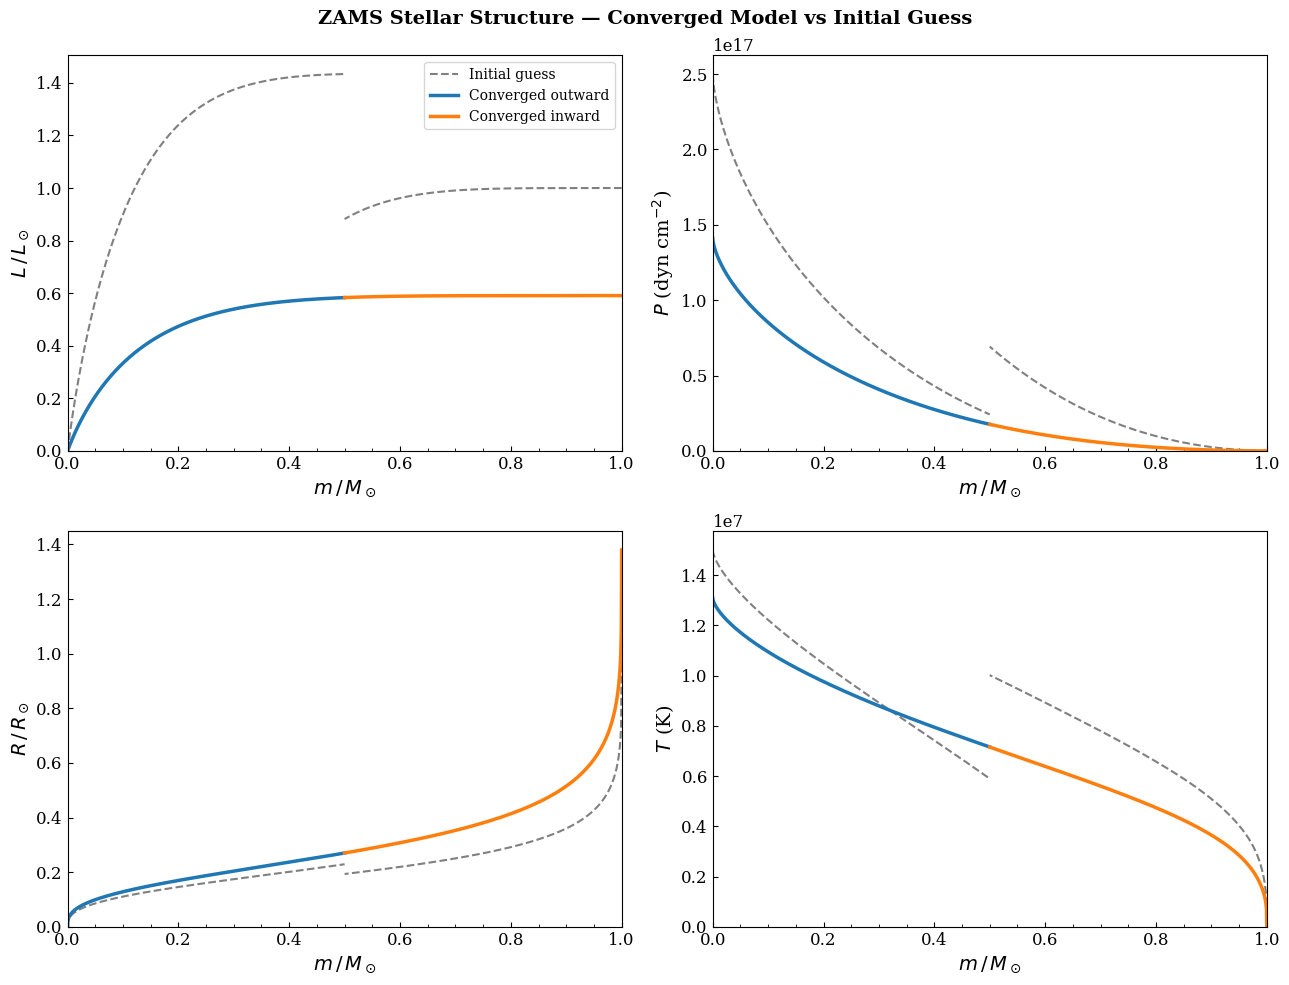

Figure saved: stellar_structure_converged.png


In [640]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('ZAMS Stellar Structure — Converged Model vs Initial Guess', fontsize=14, fontweight='bold')

ylabels = [r'$L\,/\,L_\odot$', r'$P$ (dyn cm$^{-2}$)', r'$R\,/\,R_\odot$', r'$T$ (K)']
scales  = [L_sun, 1, R_sun, 1]

for i, ax in enumerate(axes.flat):
    # Initial guess
    ax.plot(outward_guess.t/M_sun, outward_guess.y[i]/scales[i],
            ls='--', lw=1.5, c='gray', label='Initial guess')
    ax.plot(inward_guess.t/M_sun,  inward_guess.y[i]/scales[i],
            ls='--', lw=1.5, c='gray')
    # Converged solution
    ax.plot(outward_final.t/M_sun, outward_final.y[i]/scales[i],
            lw=2.5, label='Converged outward')
    ax.plot(inward_final.t/M_sun,  inward_final.y[i]/scales[i],
            lw=2.5, label='Converged inward')

    ax.set_xlabel(r'$m\,/\,M_\odot$')
    ax.set_ylabel(ylabels[i])
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.tick_params(which='both', direction='in')
    if i == 0:
        ax.legend(fontsize=10)

fig.tight_layout()
fig.savefig('figures/stellar_structure_converged.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved: stellar_structure_converged.png')

### Full stellar structure profiles (converged model):

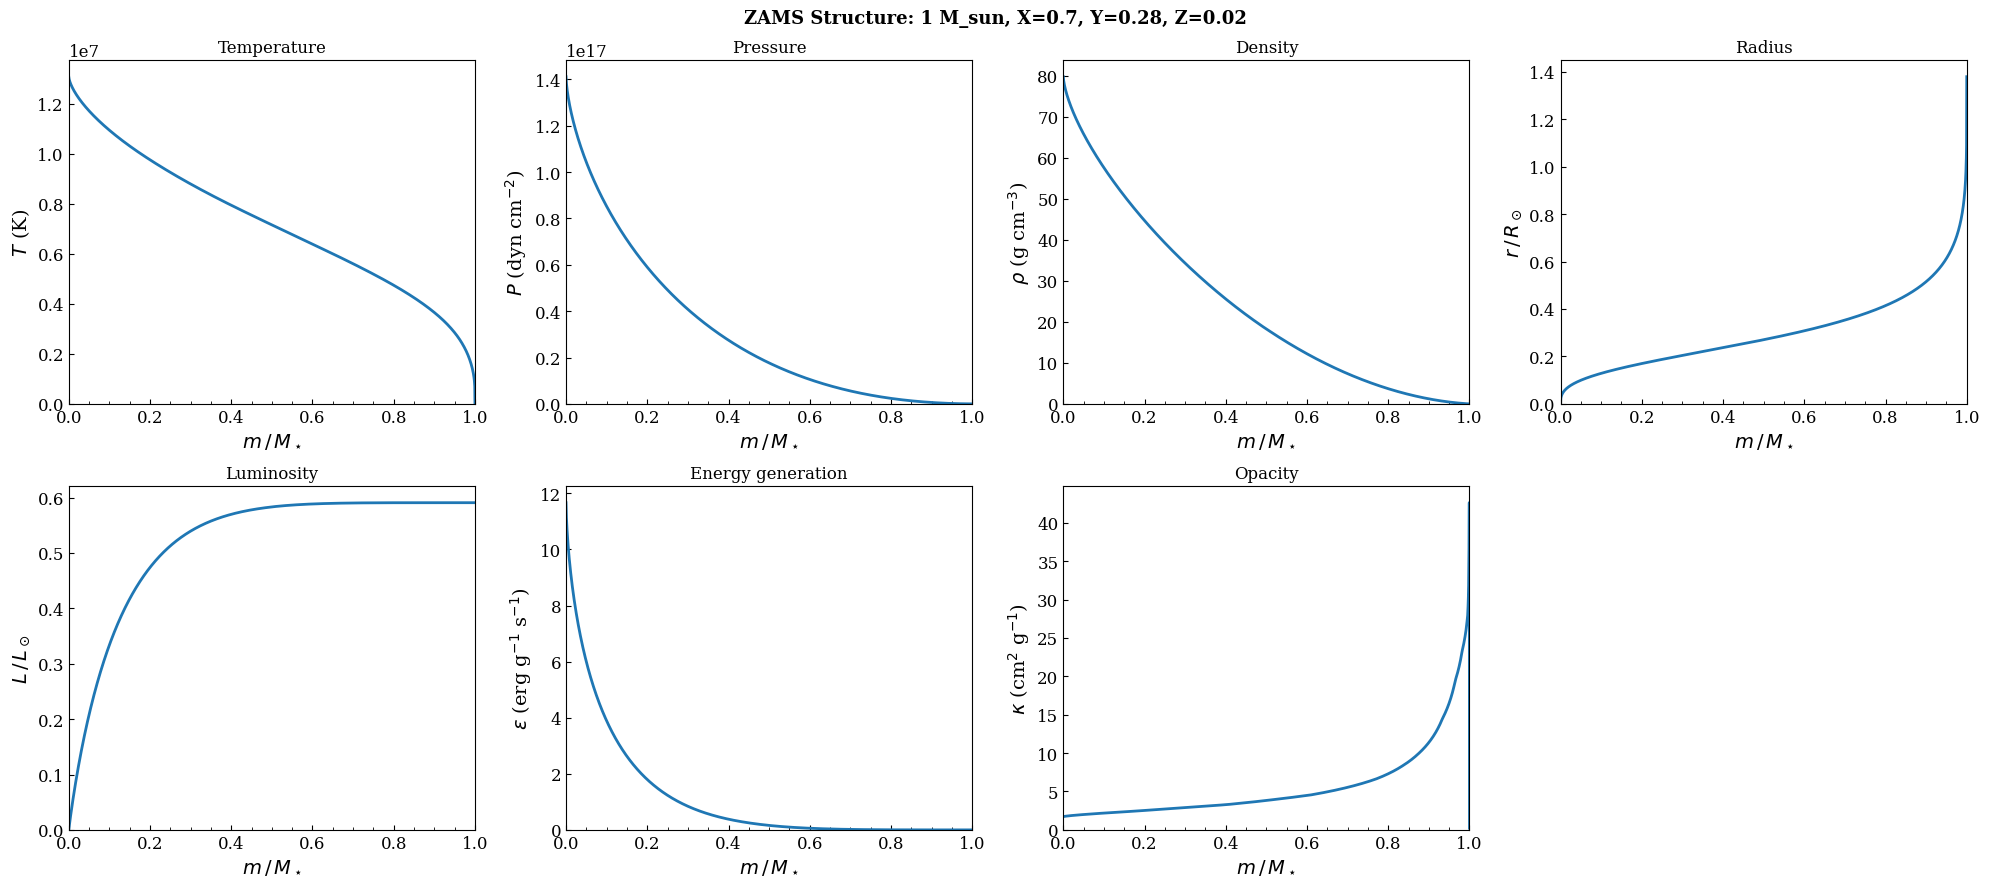

Figure saved: stellar_structure_profiles.png


In [643]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'ZAMS Structure: 1 M_sun, X={X}, Y={Y}, Z={Z}', fontsize=13, fontweight='bold')

df = results_df.copy()
mfrac = df['m'] / M_star   # fractional mass coordinate

plot_data = [
    (axes[0,0], df['T'],           r'$T$ (K)',             'Temperature'),
    (axes[0,1], df['P'],           r'$P$ (dyn cm$^{-2}$)', 'Pressure'),
    (axes[0,2], df['rho'],         r'$\rho$ (g cm$^{-3}$)','Density'),
    (axes[0,3], df['r']/R_sun,     r'$r\,/\,R_\odot$',     'Radius'),
    (axes[1,0], df['L']/L_sun,     r'$L\,/\,L_\odot$',    'Luminosity'),
    (axes[1,1], df['epsilon'],     r'$\varepsilon$ (erg g$^{-1}$ s$^{-1}$)', 'Energy generation'),
    (axes[1,2], df['kappa'],       r'$\kappa$ (cm$^2$ g$^{-1}$)', 'Opacity'),
]

# Hiding the unused 8th panel
axes[1,3].set_visible(False)
for ax, ydata, ylabel, title in plot_data:
    ax.plot(mfrac, ydata, lw=2)
    ax.set_xlabel(r'$m\,/\,M_\star$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.tick_params(which='both', direction='in')

fig.tight_layout()
fig.savefig('figures/stellar_structure_profiles.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved: stellar_structure_profiles.png')

### Temperature gradients and convective/radiative zones:

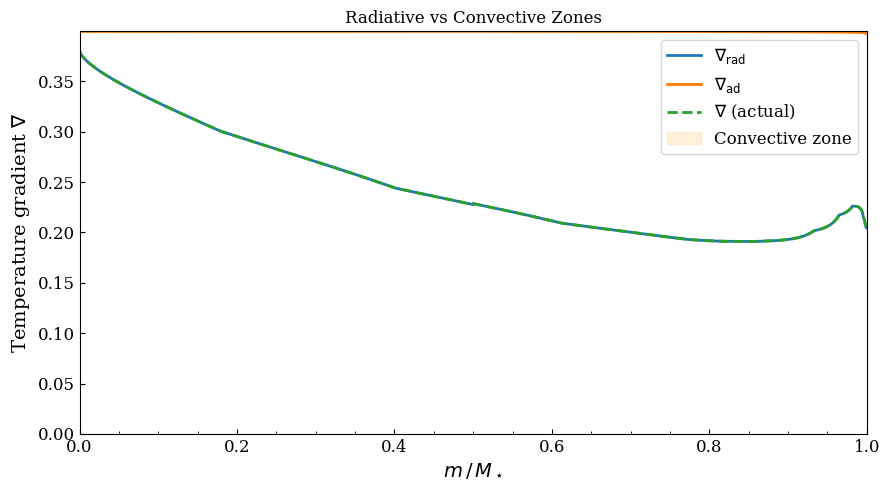

Figure saved: stellar_structure_gradients.png

Convective shells: 0 / 2000 (0.0%)


In [646]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(mfrac, df['del_rad'],    lw=2, label=r'$\nabla_{\rm rad}$')
ax.plot(mfrac, df['del_ad'],     lw=2, label=r'$\nabla_{\rm ad}$')
ax.plot(mfrac, df['del_actual'], lw=2, ls='--', label=r'$\nabla$ (actual)')

# Shading convective regions
conv_mask = df['convective'].values.astype(bool)
ax.fill_between(mfrac, 0, df['del_ad'], where=conv_mask,
                alpha=0.15, color='orange', label='Convective zone')

ax.set_xlabel(r'$m\,/\,M_\star$')
ax.set_ylabel(r'Temperature gradient $\nabla$')
ax.set_title('Radiative vs Convective Zones')
ax.set_xlim(0, 1)
ax.set_ylim(0, min(df['del_rad'].quantile(0.98)*1.1, 1.0))
ax.legend()
ax.tick_params(which='both', direction='in')
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))

fig.tight_layout()
fig.savefig('figures/stellar_structure_gradients.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved: stellar_structure_gradients.png')

n_conv = conv_mask.sum()
print(f'\nConvective shells: {n_conv} / {len(df)} ({100*n_conv/len(df):.1f}%)')

## Comparison with MESA
I load the MESA ZAMS profile (1 M_sun, Z=0.02) and compare pressure, radius, and temperature as functions of mass fraction. Shaded bands show the ±10% and ±25% margins.

In [649]:
MESA_PATH = 'MESA/profile5.data'

# Parsing MESA profile: skipping the 4-line header block (rows 0-3), then the
# column-index row, then reading data from line 6 onwards.
try:
    mesa_df = pd.read_csv(
        MESA_PATH, skiprows=5, sep=r'\s+',
        names=['zone','mass','logR','logT','logRho','logP',
               'xH','yHe','zMet','pp','cno','tri_alpha'],
        on_bad_lines='skip',
    )
    # Dropping any header rows that snuck through (non-numeric mass)
    mesa_df = mesa_df[pd.to_numeric(mesa_df['mass'], errors='coerce').notna()].copy()
    mesa_df = mesa_df.astype(float)

    # Converting log quantities back to linear CGS
    mesa_df['R_cgs'] = 10**mesa_df['logR'] * R_sun   # MESA logR is in R_sun
    mesa_df['T_K']   = 10**mesa_df['logT']
    mesa_df['P_cgs'] = 10**mesa_df['logP']            # MESA logP is log(P/dyn cm^-2)
    mesa_df['rho_cgs'] = 10**mesa_df['logRho']        # MESA logRho is log(rho/g cm^-3)

    print(f'MESA file loaded: {len(mesa_df)} zones.')
    mesa_loaded = True
except FileNotFoundError:
    print('MESA file not found. Skipping MESA comparison.')
    mesa_loaded = False

MESA file loaded: 783 zones.


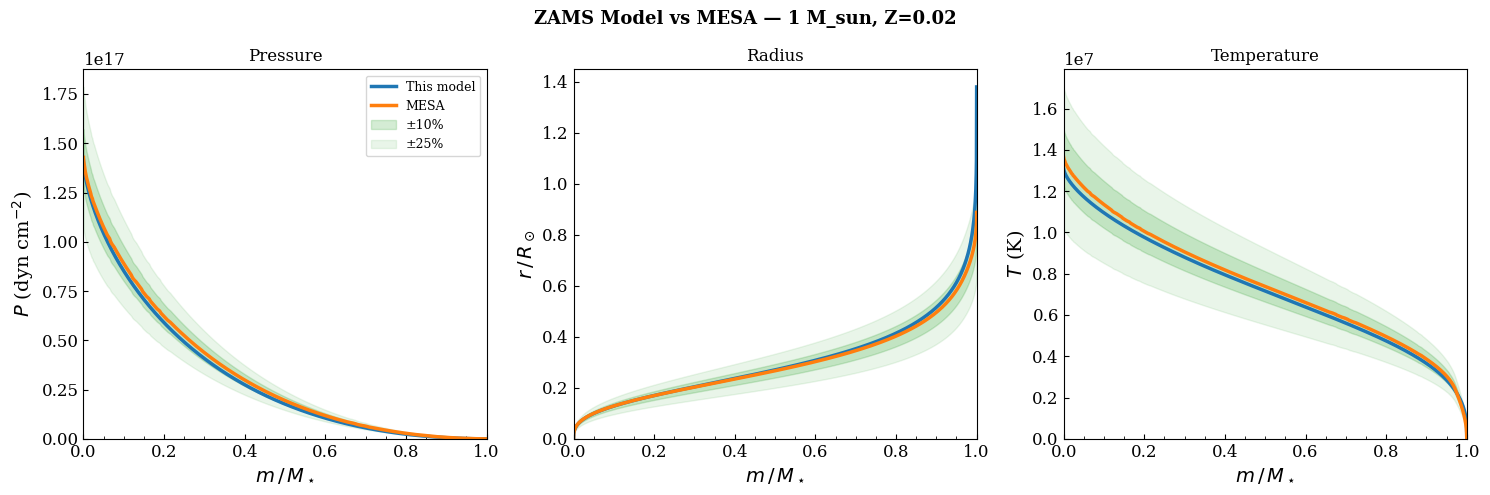

Figure saved: mesa_comparison.png


In [651]:
if mesa_loaded:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('ZAMS Model vs MESA — 1 M_sun, Z=0.02', fontsize=13, fontweight='bold')

    compare = [
        (axes[0], df['P'],             mesa_df['P_cgs'],   r'$P$ (dyn cm$^{-2}$)', 'Pressure'),
        (axes[1], df['r']/R_sun,       mesa_df['R_cgs']/R_sun, r'$r\,/\,R_\odot$', 'Radius'),
        (axes[2], df['T'],             mesa_df['T_K'],     r'$T$ (K)',        'Temperature'),
    ]

    for ax, my_y, mesa_y, ylabel, title in compare:
        # My model
        ax.plot(mfrac, my_y, lw=2.5, c='tab:blue', label='This model')
        # MESA (mass already in units of M_star from the file)
        m_mesa = mesa_df['mass'].values
        ax.plot(m_mesa, mesa_y, lw=2.5, c='tab:orange', label='MESA')
        # ±10% and ±25% shading around MESA
        ax.fill_between(m_mesa, mesa_y*0.90, mesa_y*1.10, alpha=0.20,
                        color='tab:green', label='±10%')
        ax.fill_between(m_mesa, mesa_y*0.75, mesa_y*1.25, alpha=0.10,
                        color='tab:green', label='±25%')

        ax.set_xlabel(r'$m\,/\,M_\star$')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.set_ylim(bottom=0)
        ax.tick_params(which='both', direction='in')
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
        if title == 'Pressure':
            ax.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig('figures/mesa_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Figure saved: mesa_comparison.png')

In [653]:
if mesa_loaded:
    # Reading global MESA properties from the header
    with open(MESA_PATH) as f:
        lines = f.readlines()
    header_names = lines[1].split()
    header_vals  = lines[2].split()
    header_dict  = {n: float(v) for n, v in zip(header_names, header_vals)
                    if v.replace('E','').replace('e','').replace('.','').replace('-','').replace('+','').isnumeric()
                    or 'E' in v or 'e' in v}

    # Extracting global quantities
    # msun / rsun / lsun are at the end of the header row
    msun_mesa = float(lines[2].split()[-3])
    rsun_mesa = float(lines[2].split()[-2])
    lsun_mesa = float(lines[2].split()[-1])
    Teff_mesa = float(lines[2].split()[6])
    L_mesa    = float(lines[2].split()[7]) * lsun_mesa
    R_mesa    = float(lines[2].split()[8]) * rsun_mesa
    logg_mesa = np.log10(G * M_star / R_mesa**2)

    print('=== Comparison of global stellar properties ===')
    print(f"{'Property':<20} {'This model':>15} {'MESA':>15} {'% diff':>10}")
    print('-'*62)
    for label, mine, mesa_val in [
        ('L_star [L_sun]',  L_final/L_sun, L_mesa/lsun_mesa),
        ('R_star [R_sun]',  R_final/R_sun, R_mesa/rsun_mesa),
        ('T_eff [K]', T_eff_final,  Teff_mesa),
        ('log g',     log_g_final,  logg_mesa),
    ]:
        diff = 100*(mine - mesa_val)/mesa_val
        print(f'  {label:<18} {mine:>15.4f} {mesa_val:>15.4f} {diff:>9.2f}%')

=== Comparison of global stellar properties ===
Property                  This model            MESA     % diff
--------------------------------------------------------------
  L_star [L_sun]              0.5908          0.7017    -15.80%
  R_star [R_sun]              1.3793          0.8877     55.38%
  T_eff [K]                4307.3717       5606.9900    -23.18%
  log g                       4.1585          4.5417     -8.44%


GitHub repository: https://github.com/abby-tejera/Stellar_structure_calculation.git